# Bussiness Understanding.

This project aims to understand how compensation relates to experience. 

The main objectives are to explore the data and find out:
* How is salary affected by overall years of experience?
* How does the relationship between field experience and salary differ across industries?
* How does the relationship between field experience and salary differ across gender groups?
* How does the relationship between overall experience and salary differ across age groups?



# Data Understanding.

The dataset is a salary survey that contains 28,223 rows and 18 columns.

The columns fall into four major groups: 
* Compensation (annual salary, extra compensation, currency, other_currency, income context)
* Experience and demographics (overall experience, field experience, age, gender, education, race)
* Job context (industry, job title, job title context), and location (country, state, city)
* timestamp for each response.


# Data Preparation

### <u>Loading the dataset<u>

In [360]:
# Importing pandas, numpy, matplotlib and seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [361]:
df = pd.read_csv("Salary Data - Form Responses 1.csv")
df.shape

(28223, 18)

The dataset has 28,223 rows and 18 columns.

### <u>Standardizing the column names<u>

In [362]:
df.columns

Index(['Timestamp', 'How old are you?', 'What industry do you work in?',
       'Job title',
       'If your job title needs additional context, please clarify here:',
       'What is your annual salary? (You'll indicate the currency in a later question. If you are part-time or hourly, please enter an annualized equivalent -- what you would earn if you worked the job 40 hours a week, 52 weeks a year.)',
       'How much additional monetary compensation do you get, if any (for example, bonuses or overtime in an average year)? Please only include monetary compensation here, not the value of benefits.',
       'Please indicate the currency',
       'If "Other," please indicate the currency here: ',
       'If your income needs additional context, please provide it here:',
       'What country do you work in?',
       'If you're in the U.S., what state do you work in?',
       'What city do you work in?',
       'How many years of professional work experience do you have overall?',
       

In [363]:
df = df.rename(columns= {
    "How old are you?" : "age",
    "What industry do you work in?" : "industry",
    "If your job title needs additional context, please clarify here:" : "job_title_context",
    "What is your annual salary? (You'll indicate the currency in a later question. If you are part-time or hourly, please enter an annualized equivalent -- what you would earn if you worked the job 40 hours a week, 52 weeks a year.)" : "annual salary",
    "How much additional monetary compensation do you get, if any (for example, bonuses or overtime in an average year)? Please only include monetary compensation here, not the value of benefits." : "extra_compensation",
    "Please indicate the currency" : "currency",
    'If "Other," please indicate the currency here: ' : "other_currency",
    "If your income needs additional context, please provide it here:" : "income_context",
    "What country do you work in?" : "country",
    "If you're in the U.S., what state do you work in?" : "state",
    "What city do you work in?" : "city",
    "How many years of professional work experience do you have overall?" : "overall_exp",
    "How many years of professional work experience do you have in your field?" : "field_exp",
    "What is your highest level of education completed?" : "education",
    "What is your gender?" : "gender",
    "What is your race? (Choose all that apply.)" : "race"
})

df.columns = (
    df.columns.str.strip()
    .str.replace(" ", "_")
    .str.lower()
)

df.columns

Index(['timestamp', 'age', 'industry', 'job_title', 'job_title_context',
       'annual_salary', 'extra_compensation', 'currency', 'other_currency',
       'income_context', 'country', 'state', 'city', 'overall_exp',
       'field_exp', 'education', 'gender', 'race'],
      dtype='str')

### <u>Ensuring the columns contain values of the expected data type<u>

In [364]:
df.dtypes

timestamp                 str
age                       str
industry                  str
job_title                 str
job_title_context         str
annual_salary             str
extra_compensation    float64
currency                  str
other_currency            str
income_context            str
country                   str
state                     str
city                      str
overall_exp               str
field_exp                 str
education                 str
gender                    str
race                      str
dtype: object

In [365]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df["annual_salary"] = (
    df["annual_salary"].str.strip()
    .str.replace(",", "")
)
df["annual_salary"] = df["annual_salary"].astype("float64")

The column timestamp has been converted from a string to datetime.

The column annual_salary has been converted from string to float.

### <u>Standardizing and validating the values in the columns<u>

Standadizing and validating the values in the column other_currency by turnig them into their short form version and in upper case.

For values that are not valid, ie. not currencies, they are converted to NaN.

In [366]:
# Strip whitespace first so the keys match exactly
df['other_currency'] = df['other_currency'].astype(str).str.strip()

currency_mapping = {
    # Previously imputed missing values
    'Not Applicable': 'not applicable',
    
    # --- USD ---
    'USD': 'usd',
    'US Dollar': 'usd',
    'American Dollars': 'usd',
    
    # --- EUR ---
    'EUR': 'eur',
    'Euro': 'eur',
    
    # --- GBP ---
    'GBP': 'gbp',
    
    # --- INR ---
    'INR': 'inr',
    'Indian rupees': 'inr',
    'INR (Indian Rupee)': 'inr',
    'Rupees': 'inr',
    'Rupees ': 'inr',
    'Rs': 'inr',              
    'inr': 'inr',
    
    # --- PKR ---
    'PKR': 'pkr',
    'pkr': 'pkr',
    
    # --- AUD ---
    'AUD': 'aud',
    'Australian Dollars ': 'aud',
    'AUD Australian ': 'aud',
    
    # --- NZD ---
    'NZD': 'nzd',
    
    # --- CAD ---
    'CAD': 'cad',
    'Canadian ': 'cad',
    'Canadian': 'cad',
    'canadian': 'cad',
    
    # --- BRL ---
    'BRL': 'brl',
    'BRL (R$)': 'brl',
    'BR$': 'brl',
    
    # --- ARS ---
    'ARS': 'ars',
    'Argentinian peso (ARS)': 'ars',
    'Argentine Peso': 'ars',
    'Peso Argentino': 'ars',
    
    # --- MXN ---
    'MXN': 'mxn',
    'Mexican pesos': 'mxn',
    'Mexican Pesos': 'mxn',
    
    # --- COP ---
    'COP': 'cop',
    'Pesos Colombianos': 'cop',
    
    # --- PHP ---
    'PHP': 'php',
    'Php': 'php',
    'PhP (Philippine Peso)': 'php',
    'Philippine Peso': 'php',
    'Philippine peso (PHP)': 'php',
    'Philippine Pesos': 'php',
    
    # --- SGD ---
    'SGD': 'sgd',
    'Sgd': 'sgd',
    'SGD ': 'sgd',
    'Singapore Dollara': 'sgd',
    
    # --- MYR ---
    'MYR': 'myr',
    'RM': 'myr',
    
    # --- CNY / RMB ---
    'CNY': 'cny',
    'RMB (chinese yuan)': 'cny',
    'China RMB': 'cny',
    
    # --- TWD ---
    'NTD': 'twd',
    'Taiwanese dollars': 'twd',
    
    # --- KRW ---
    'KRW': 'krw',
    'KRW (Korean Won)': 'krw',
    'Korean Won ': 'krw',
    
    # --- CHF ---
    'CHF': 'chf',
    
    # --- SEK ---
    'SEK': 'sek',
    
    # --- NOK ---
    'NOK': 'nok',
    'Nok': 'nok',
    'Norwegian kroner (NOK)': 'nok',
    
    # --- DKK ---
    'DKK': 'dkk',
    'Dkk': 'dkk',
    'DKK ': 'dkk',
    'Danish Kroner': 'dkk',
    
    # --- CZK ---
    'CZK': 'czk',
    'Czk': 'czk',
    'czech crowns': 'czk',
    
    # --- PLN ---
    'PLN': 'pln',
    'PLN (Polish zloty)': 'pln',
    'Polish Złoty': 'pln',
    'PLN (Zwoty)': 'pln',
    
    # --- TRY ---
    'TRY': 'try',
    
    # --- ILS / NIS ---
    'ILS': 'ils',
    'Ils': 'ils',
    'ILS/NIS': 'ils',
    'NIS (new Israeli shekel)': 'ils',
    'Israeli Shekels': 'ils',
    
    # --- ZAR ---
    'ZAR': 'zar',
    
    # --- SAR ---
    'SAR': 'sar',
    
    # --- KWD ---
    'KWD': 'kwd',
    
    # --- THB ---
    'THB': 'thb',
    'THAI BAHT': 'thb',
    'Thai Baht ': 'thb',
    'Thai Baht': 'thb',
    
    # --- IDR ---
    'IDR': 'idr',
    'IDR ': 'idr',
    
    # --- TTD ---
    'TTD': 'ttd',
    
    # --- LKR ---
    'LKR': 'lkr',
    
    # --- NGN ---
    'NGN': 'ngn',
    
    # --- TZS ---
    'TZS': 'tzs',
    
    # --- ZMW ---
    'ZMW': 'zmw',
    
    # --- HRK ---
    'croatian kuna': 'hrk',
    
    # --- HKD ---
    'HKD': 'hkd',
    
    # --- OTHER (literal) ---
    'other': 'other',
    
    # --- INVALID / NON-CURRENCY → NaN ---
    'na': np.nan,
    'Na ': np.nan,
    'N/a': np.nan,
    '-': np.nan,
    '0': np.nan,
    '1': np.nan,
    '5': np.nan,
    '55,000': np.nan,
    '47000': np.nan,
    'ekignkfb': np.nan,
    '$76,302.34': np.nan,
    'My bonus is based on performance up to 10% of salary': np.nan,
    'I work for an online state university, managing admissions data. Not direct tech support. ': np.nan,
    'Base plus Commission ': np.nan,
    'Additonal = Bonus plus stock': np.nan,
    'Overtime (about 5 hours a week) and bonus': np.nan,
    '6000 in stock grants annually': np.nan,
    'Many non-salary benefits - travel, free healthcare for self, very low for family, non-taxable housing allowance ': np.nan,
    'Equity': np.nan,
    'RSU / equity': np.nan,
    'Stock ': np.nan,
    'It’s marketed as £22000 but we get paid pro-rats, so no pay for the school holidays.': np.nan,
    'additional compensation is for overtime (i am paid hourly) so it varies. i have included an estimate': np.nan,
    'Option to get 2x or 1.5x if taking on a weekend day in the summer': np.nan,
    'up to 12% annual bonus': np.nan,
    'AUD & NZD are not the same currency...': np.nan,
    "AUD and NZD aren't the same currency, and have absolutely nothing to do with each other :(": np.nan,
    'Converted mine into USD for your easyness': np.nan,
}

# Apply the mapping
df['other_currency'] = df['other_currency'].map(currency_mapping)

df["other_currency"] = df["other_currency"].str.upper()



If currency is "Other" but other_currency contains a value that actually belongs in the currency list, move it to currency and clear other_currency.

Any row where currency is NOT "Other" should not have a value in other_currency. Clear those entries.

In [367]:
valid_currencies = {'USD', 'GBP', 'CAD', 'EUR', 'AUD/NZD', 'Other', 'CHF', 'ZAR', 'SEK', 'HKD', 'JPY'}


mask_promote = (df['currency'] == 'Other') & (df['other_currency'].isin(valid_currencies))
df.loc[mask_promote, 'currency'] = df.loc[mask_promote, 'other_currency']
df.loc[mask_promote, 'other_currency'] = np.nan


mask_clear = (df['currency'] != 'Other') & (df['other_currency'].notna())
df.loc[mask_clear, 'other_currency'] = np.nan

----------------------------------------------------------------------------------------------------------------------------------------

I GIVE UP ON THIS ONE.

The column country has multiple unique values that need to be standardized.

In [368]:
len(list(df["country"].unique()))



391

Country has a total of 381 unique values that need to be standadized. 

This number can be reduced by turning them all to lowercase, removing commas, full stops etc. 

In [369]:
df["country"] = (
    df["country"].str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "")
    .str.replace("'", "")
    .str.replace(".", "")
    .str.replace(",", "")
)

len(list(df["country"].unique()))

257

That has reduced the values down to 249.

In [370]:
# First, let's create a more comprehensive mapping
country_mapping = {
    # United States variations
    'usaa': 'usa',
    'usa': 'usa',
    'usausa': 'usa',
    'usa_of_usa': 'usa',
    'usad': 'usa',
    'usausan': 'usa',
    'usausas': 'usa',
    'usaap': 'usa',
    'usas': 'usa',
    'usaw': 'usa',
    'usaae': 'usa',
    'usaab': 'usa',
    'usaa_tomorrow': 'usa',
    'usads': 'usa',
    'usaat': 'usa',
    'unitedstates': 'usa',
    'united_statusa': 'usa',
    'uniteed_states': 'usa',
    'united_stares': 'usa',
    'united_stated': 'usa',
    'unite_states': 'usa',
    'unitedstates': 'usa',
    'united_statues': 'usa',
    'untied_states': 'usa',
    'united_sttes': 'usa',
    'unitied_states': 'usa',
    'uniter_statez': 'usa',
    'united_statss': 'usa',
    'united__states': 'usa',
    'the_usa': 'usa',
    'united_sates': 'usa',
    'united_statees': 'usa',
    'united_stattes': 'usa',
    'united_statea': 'usa',
    'united_statws': 'usa',
    'unites_states': 'usa',
    'uniyed_states': 'usa',
    'uniyes_states': 'usa',
    'uniited_states': 'usa',
    'unted_states': 'usa',

    # United Kingdom variations
    'uk': 'uk',
    'united_kindom': 'uk',
    'britain': 'uk',
    'uk_uk': 'uk',
    'uk_(uk)': 'uk',
    'uk_gb': 'uk',
    'unites_kingdom': 'uk',
    'united_kingdom': 'uk',
    'englang': 'uk',
    'ukk': 'uk',
    'uk_(northern_uk)': 'uk',
    'uk_remote': 'uk',
    'uk_but_for_globally_fully_remote_company' : "uk",

    # Canada variations
    'canada': 'canada',
    'canadaada': 'canada',
    'canadada': 'canada',
    'canadaada_and_usaa': 'canada',
    'csnada': 'canada',
    'canadaad': 'canada',
    'canadaada': 'canada',
    'i_am_located_in_canadaada_but_i_work_forada' : "canada",
    'canadaadá': 'canada',

    # Australia variations
    'ausatralia': 'australia',
    'ausatria': 'australia',
    'ausatrali': 'australia',
    'ausatria_but_i_work_remotely_for_a_dutch/british_company': 'australia',
    'ausatralian': 'australia',

    # Other common countries
    'the_netherlands': 'netherlands',
    'nederland': 'netherlands',
    'nl': 'netherlands',

    # Add more mappings as needed...
    'méxico': 'mexico',
    'méxico': 'mexico',
    'deutschland': 'germany',
    'españa': 'spain',
    'francia': 'france',
    'italia': 'italy',
    'italy_(south)': 'italy',
    'brasil': 'brazil',
    'brasil': 'brazil',
    'argentina': 'argentina',

    # Special cases that should be handled di
    'n/a_(remote_from_wherever_i_want)': 'remote',
    'remote': 'remote',
    'remote_(philippines)': 'remote',
    'n/a': 'other',
    'ausatria': 'australia',
    'ausatrali': 'australia',
    'ausatria_but_i_work_remotely_for_a_dutch/british_company': 'australia',
    'ausatralian': 'australia',

    # Other common countries
    'the_netherlands': 'netherlands',
    'nederland': 'netherlands',
    'nl': 'netherlands',

    # Add more mappings as needed...
    'méxico': 'mexico',
    'méxico': 'mexico',
    'deutschland': 'germany',
    'españa': 'spain',
    'francia': 'france',
    'italia': 'italy',
    'italy_(south)': 'italy',
    'brasil': 'brazil',
    'brasil': 'brazil',
    'argentina': 'argentina',

    # Special cases that should be handled di
    'n/a_(remote_from_wherever_i_want)': 'remote',
    'remote': 'remote',
    'remote_(philippines)': 'remote',
    'n/a': 'other',
    'na': 'other',
    'nan': 'other',
    '1': 'other',
    'y': 'other',
    'yy': 'other',
    'united_y': 'other',
}

# Apply the mapping
df['country'] = df['country'].replace(country_mapping, regex=False)

In [371]:
len(list(df["country"].unique()))


214

### <u>Handling missing values.<u>

In [372]:
df.isna().sum()

timestamp                 0
age                       0
industry                 86
job_title                 5
job_title_context     20930
annual_salary             0
extra_compensation     7374
currency                  0
other_currency        28081
income_context        25170
country                   2
state                  5076
city                     85
overall_exp               0
field_exp                 0
education               241
gender                  186
race                    197
dtype: int64

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

The colums industry, job_title, country, city, education and race have missing values.

Since there is no way of finding appropriate values to fill into these empty slots, it is best to drop the rows that contain missing values in the industry column.

Since the number of rows with missing values in these columns are less than 5%, dropping those should not have any significant impact on any future analysis done.

In [373]:
df = df.dropna(subset= ["industry", "job_title", "city", "country", "education", "race"])

df[["industry", "job_title", "city", "country", "education", "race"]].isna().sum()

industry     0
job_title    0
city         0
country      0
education    0
race         0
dtype: int64

All the rows with missing values in the those columns have been dropped.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Since the job_title_context columns only contains additional context of the job title, it can be concluded that the rows with missing values in this column did not require any aditional context.

These missing values can then be filled with "No additional context"

In [374]:
df["job_title_context"] = df["job_title_context"].fillna("No additional context")

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

The column other_currency has 27,479.

This column should only filled in if the value in the currency column is "Other".

In [375]:
df["currency"].unique()

<StringArray>
[    'USD',     'GBP',     'CAD',     'EUR', 'AUD/NZD',   'Other',     'CHF',
     'ZAR',     'SEK',     'HKD',     'JPY']
Length: 11, dtype: str

All the rows who have the value "Other" in the column currency and have a missing value in the column other_currency should be dropped.

In [376]:
df = df[~((df["currency"] == "Other") & (df["other_currency"].isna()))]

All the rows where the value in the the value in the column currency is not "Other" and the value in the column other_currency is missing will have that missing value filled with "Not Applicable".

In [377]:
df["other_currency"] = np.where(
    (df["currency"] != "Other") & (df["other_currency"].isna()),
    "Not Applicable",
    df["other_currency"]
)

df["other_currency"].isna().sum()

np.int64(0)

All the missing values in the column other_currency have now been cleared.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Since the column income_context only gets filled with a value if there is a need to add more context on the income, the missing values can be filled with "No additional context".

In [378]:
df['income_context'] = df['income_context'].fillna("No additional context")
df["income_context"].isna().sum()

np.int64(0)

All missing values in the income_context column have been filled with "No additional context"

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

The column extra_compensation only needs to get filled in if there is any extra monetary compensation.

Since this is the case, the rows with missing values in this column can be filled in with 0 and we assume that there was no extra monetary compensation.

In [379]:
df['extra_compensation'] = df['extra_compensation'].fillna(0)
df["extra_compensation"].isna().sum()

np.int64(0)

All the rows with missing values in the column extra_compensation have had those missing values filled.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In the column gender, we can assume that the individual answering the survey was not comfortable sharing their gender and fill in the missing values with "Prefer not to answer".

In [380]:
df['gender'] = df['gender'].fillna("Prefer not to answer")
df["gender"].isna().sum()

np.int64(0)

The missing values in the column gender were filled in with the value "Rather not say".

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In the column states, a value is only expected if the contry is in the USA.

If the value in the column country is USA and the value in the column states is missing, it can be filled in with "Not specified".

If the value in the country column is not USA and the value in the states column is missing, it can be filled in with "Not needed".

In [381]:
df['state'] = np.where(
    (df['country'] != 'usa') & (df['state'].isna()),
    'Not needed',
    df['state'].fillna('Not specified')
)

In [382]:
df.isna().sum()

timestamp             0
age                   0
industry              0
job_title             0
job_title_context     0
annual_salary         0
extra_compensation    0
currency              0
other_currency        0
income_context        0
country               0
state                 0
city                  0
overall_exp           0
field_exp             0
education             0
gender                0
race                  0
dtype: int64

There are no more missing values in the dataframe.

### <u>Handling duplicates<u>

In [383]:
df.duplicated(subset=["timestamp", "age", "industry", "job_title", "annual_salary", "currency", "country"]).sum()

np.int64(0)

There are no duplicated columns with the relevant data.

# Bivariate Analysis

### <u>How is salary affected by overall experience?<u>

In order to check this, a new column with all the salaries in one currency will need to be created. This column will be called salary_usd and will have all the salaries converted to usd.

The bonuses and extra compensation will also need to be converted to usd. The converted values are in the column bonus_usd.

Another column called total_compensation will also be created to store the total ammount of money earned. This will be salary + extra compensation

In [ ]:
conversion_rates = {
    # Main currency column values
    'USD': 1.0,
    'GBP': 0.78,
    'CAD': 1.37,
    'EUR': 0.92,
    'AUD/NZD': 1.52,
    'CHF': 0.90,
    'ZAR': 18.65,
    'SEK': 10.80,
    'HKD': 7.82,
    'JPY': 157.50,

    # Other currency column values
    'INR': 83.30,
    'ARS': 860.00,
    'MYR': 4.72,
    'NOK': 10.85,
    'BRL': 5.85,
    'DKK': 6.85,
    'TTD': 6.75,
    'MXN': 16.70,
    'CZK': 23.20,
    'PHP': 57.50,
    'PLN': 3.95,
    'TRY': 32.50,
    'CNY': 7.25,
    'ILS': 3.75,
    'AUD': 1.52,
    'NZD': 1.65,
    'TWD': 32.50,
    'SGD': 1.35,
    'KRW': 1365.00,
    'THB': 36.50,
    'IDR': 15800.00,
    'LKR': 295.00,
    'SAR': 3.75,
    'HRK': 7.50,
    'NGN': 1500.00,
    'TZS': 2750.00,
    'COP': 4200.00,
    'ZMW': 24.50,
    'PKR': 277.00,
    'Not Applicable': 1.0
}

def get_exchange_rate(row):
    if row['currency'] == 'Other':
        return conversion_rates.get(row['other_currency'], 1.0)
    else:
        currency_key = row['currency']
        if currency_key == 'AUD/NZD':
            return conversion_rates.get('AUD', 1.0)
        return conversion_rates.get(currency_key, 1.0)

df['exchange_rate'] = df.apply(get_exchange_rate, axis=1)

df['salary_usd'] = df['annual_salary'] * df['exchange_rate']

df['bonus_usd'] = df['extra_compensation'] * df['exchange_rate']

df['total_compensation_usd'] = df['salary_usd'] + df['bonus_usd']

The data is then grouped by overall_exp and the mean total compensation by salary is calculated. 

In [385]:
temp_df1 = df.groupby('overall_exp')['total_compensation_usd'].mean().round(2)
temp_df1

overall_exp
1 year or less      7.537287e+08
11 - 20 years       6.400645e+06
2 - 4 years         3.652799e+07
21 - 30 years       4.345540e+09
31 - 40 years       3.386546e+05
41 years or more    1.289858e+05
5-7 years           6.058584e+08
8 - 10 years        1.195189e+08
Name: total_compensation_usd, dtype: float64

This data suggests that individuals with 1 year or less of expirience earn about 750 million usd. 

This indicates there there are most likely outliers in the data and the mean has been heavily skewed.

In [386]:
temp_df1 = df.groupby('overall_exp')['total_compensation_usd'].median().round(2)
temp_df1

overall_exp
1 year or less      57000.0
11 - 20 years       89990.0
2 - 4 years         62400.0
21 - 30 years       95000.0
31 - 40 years       96000.0
41 years or more    99000.0
5-7 years           71500.0
8 - 10 years        80000.0
Name: total_compensation_usd, dtype: float64

Using the median instead provides values that are far more realistic since the median is not as affected by outliers in the data set.

To deal with the outliers, an upper and lower limit will be set and any values outside this range will be dropped.

The upper limit = Q3 + (1.5 * IQR). Q3 is the upper quartile.

The lower limit = Q1 - (1.5 * IQR). Q1 is the lower quartile.

IQR is the interquartile range.

Since the lower limit has a chance of being pushed down into the negatives, a hard limit if 5000 will be set.

In [387]:
Q1 = df['total_compensation_usd'].quantile(0.25)
Q3 = df['total_compensation_usd'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

if lower_limit < 5000:
    lower_limit = 5000

df_cleaned = df[(df['total_compensation_usd'] >= lower_limit) & (df['total_compensation_usd'] <= upper_limit)].copy()


print(f"Dropped {len(df) - len(df_cleaned)} outliers.")

Dropped 1701 outliers.


A total a 1,701 rows were dropped since the contained outliers.

Now to check the mean and median of the cleaned data:

In [388]:
temp_df1 = df_cleaned.groupby('overall_exp')['total_compensation_usd'].median().round(2)
temp_df1

overall_exp
1 year or less      57000.0
11 - 20 years       85000.0
2 - 4 years         62000.0
21 - 30 years       90000.0
31 - 40 years       91000.0
41 years or more    94240.0
5-7 years           70000.0
8 - 10 years        77000.0
Name: total_compensation_usd, dtype: float64

In [389]:
temp_df1 = df_cleaned.groupby('overall_exp')['total_compensation_usd'].mean().round(2)
temp_df1

overall_exp
1 year or less      66002.00
11 - 20 years       93446.14
2 - 4 years         69587.23
21 - 30 years       97629.86
31 - 40 years       96611.06
41 years or more    94882.62
5-7 years           77652.51
8 - 10 years        85626.10
Name: total_compensation_usd, dtype: float64

The difference between the 2 is now a lot smaller and acceptable. 

The mean can now be used.

The data will be plotted on a bar plot since it is categorical data and numerical data.

C:\Users\Shaun Raymond\AppData\Local\Temp\ipykernel_22344\682031438.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cleaned, x='overall_exp', y='total_compensation_usd', order=experience_order, palette='viridis', errorbar='sd')


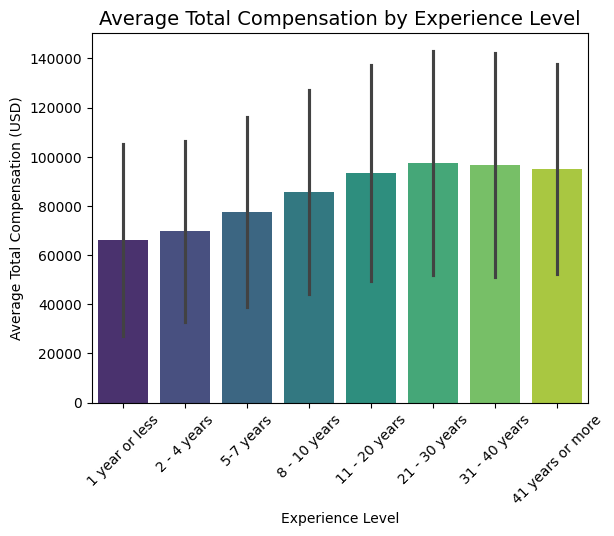

In [390]:
experience_order = [
    '1 year or less',
    '2 - 4 years',
    '5-7 years',
    '8 - 10 years',
    '11 - 20 years',
    '21 - 30 years',
    '31 - 40 years',
    '41 years or more'
]


sns.barplot(data=df_cleaned, x='overall_exp', y='total_compensation_usd', order=experience_order, palette='viridis', errorbar='sd')
plt.xticks(rotation=45)
plt.title('Average Total Compensation by Experience Level', fontsize=14)
plt.xlabel('Experience Level')
plt.ylabel('Average Total Compensation (USD)')
plt.show()

From the bar plot, as the overall experience increases, so does the salary.

However, the salary increase is not perfectly linear. The salary increase gets smaller as the overall experience increases.

The error bars indicate that there is a high standaerd deviation. Therefore, it can be concluded that other variables create a wide salary range even among people with a similar amount of experience. 

# Multivariate Analysis.

### <u>Relationship between field experience and salary.<u>

To explore this relationship a 3rd variable, which will be the industry column, needs to be introduced.

Since the variables field_exp and total_compensation_usd are numerical variable, a scatter plot could be used to visualize their relationship. However, the third variable would make the scatter plot difficult to interperate. 

Therefore, sns.relplot() will be used to create multiple line plots on one axis and assign different colors to each in order to be able to tell the difference.

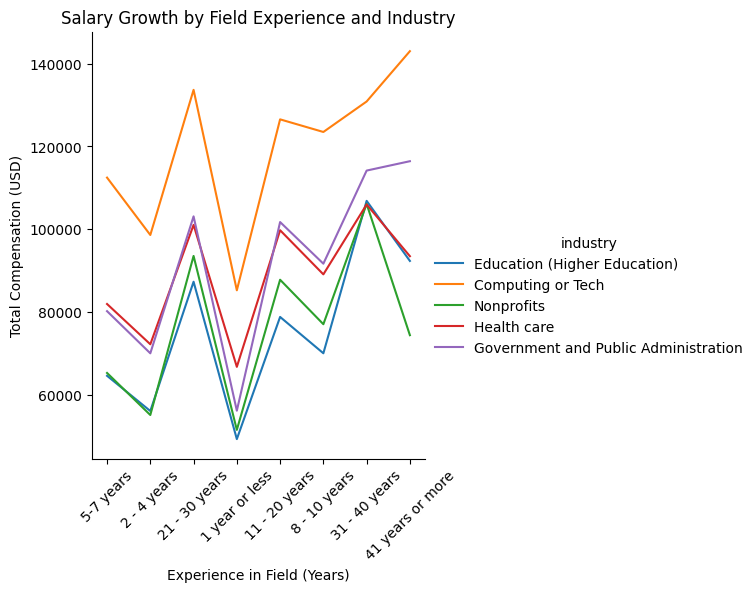

In [391]:

top_industries = df_cleaned['industry'].value_counts().sort_values(ascending=False).iloc[:5].index
df_filtered = df_cleaned[df_cleaned['industry'].isin(top_industries)]


sns.relplot(
    data = df_filtered,
    x = 'field_exp',
    y = 'total_compensation_usd',
    hue = 'industry',
    kind = 'line',
    errorbar = None
)

# sns.relplot(
#     data = df_filtered,
#     x = 'field_exp',
#     y = 'total_compensation_usd',
#     col = 'industry',    # <--- This creates a separate plot for each industry automatically!
#     col_wrap = 3, 
#     errorbar = None,
#     kind ='line'
# )

plt.xlabel("Experience in Field (Years)")
plt.ylabel("Total Compensation (USD)")
plt.title('Salary Growth by Field Experience and Industry')
plt.xticks(rotation=45)
plt.show()

From the plot above, it can be determined that;

* The choice of field establishes a different salary range. The fact that each industry operates within its own salary range provides an explanation for the high variance that was seen earlier in the analysis incolcing overall_exp and salary.

* At early stages of a career, the salary differs by field. This is shown by the fact that a career in computing and tech has a significantly higher starte=ing salary than a career in nonprofits.

### <u>Relationship between gender, experience and salary<u>

Gender is introduced here as the third variable. The other 2 variables are still field_exp and total_compensation_usd.

Since both of those are numerical, a scatter plot with a third categorical variable would get cluttered, so sns.relplot() with kind='line' is used again.

Before plotting, the gender column is checked with value_counts(dropna=False).

Some of the values in gender do not occur frequently enough so they need to be filtered out since they cannot be used in the plotting for this reason.

field_exp is reordered using the same experience_order list from before, keeping the x-axis in real experience order instead of a random one.

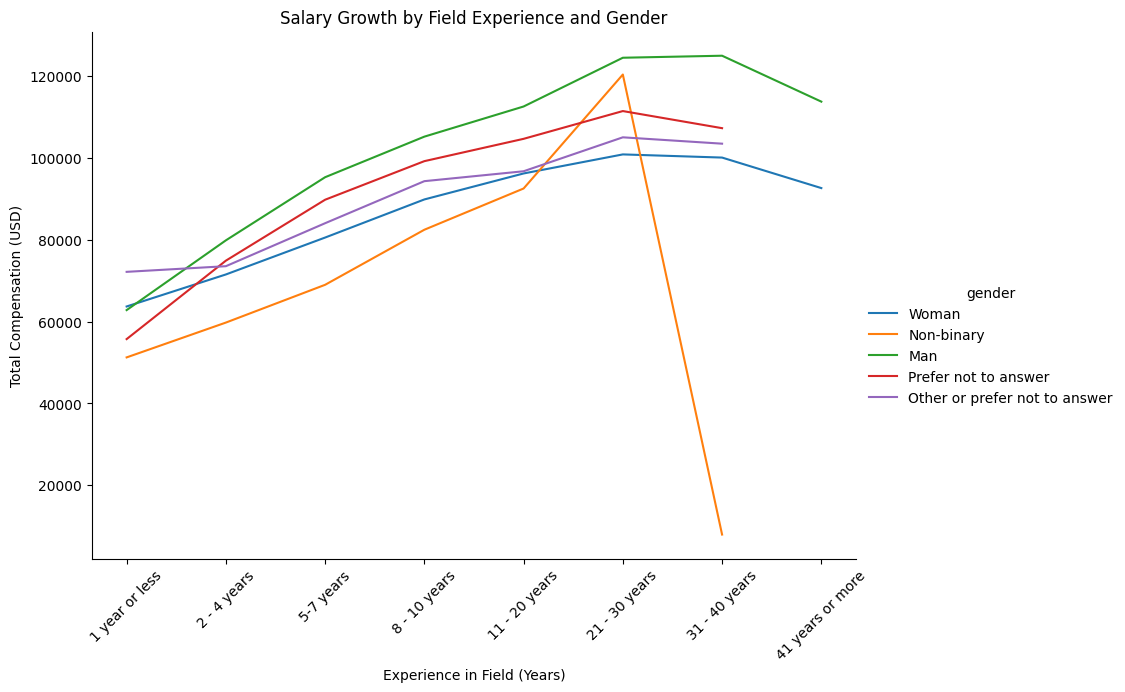

In [396]:
gender_counts = df_cleaned['gender'].value_counts()
valid_genders = gender_counts[gender_counts >= 30].index
df_gender_filtered = df_cleaned[df_cleaned['gender'].isin(valid_genders)].copy()

# Put field_exp back in true experience order, same list used earlier
df_gender_filtered['field_exp'] = pd.Categorical(
    df_gender_filtered['field_exp'],
    categories=experience_order,
    ordered=True
)

sns.relplot(
    data=df_gender_filtered,
    x='field_exp',
    y='total_compensation_usd',
    hue='gender',
    kind='line',
    errorbar=None,
    height=6,
    aspect=1.5
)

plt.xlabel("Experience in Field (Years)")
plt.ylabel("Total Compensation (USD)")
plt.title('Salary Growth by Field Experience and Gender')
plt.xticks(rotation=45)
plt.show()

Most groups show a general upward trend in salary as experience increases, peaking around the 21–30 years experience bracket.

Man is consistently the highest earners across nearly all experience levels, followed by those who prefer not to say.

Non-binary line has a dramatic drop at the 31–40 years bracket. This suggests that there was a small sample size for non binary or  a data reliability issue

### <u>Relationship between experience, age and salary<u>

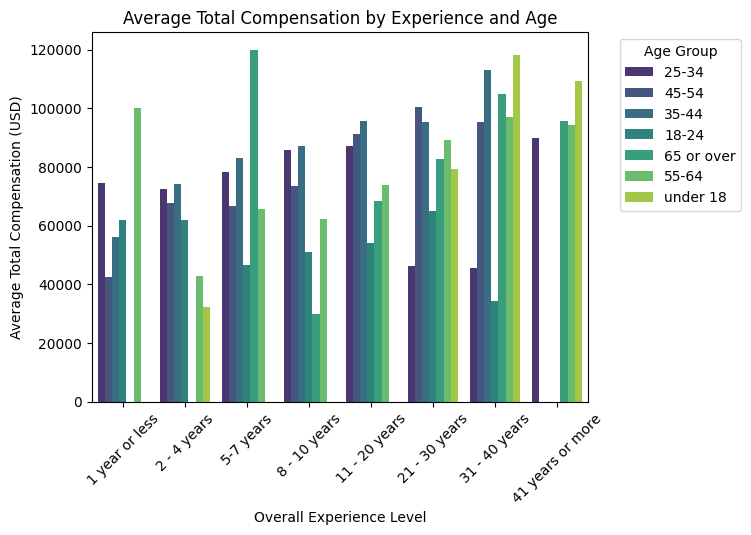

In [405]:
experience_order = [
    '1 year or less',
    '2 - 4 years',
    '5-7 years',
    '8 - 10 years',
    '11 - 20 years',
    '21 - 30 years',
    '31 - 40 years',
    '41 years or more'
]

sns.barplot(
    data=df_cleaned,
    x='overall_exp',
    y='total_compensation_usd',
    hue='age',
    order = experience_order,
    errorbar = None,
    palette='viridis'
)

plt.title('Average Total Compensation by Experience and Age')
plt.xlabel('Overall Experience Level')
plt.ylabel('Average Total Compensation (USD)')
plt.xticks(rotation=45)
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Compensation generally rises with experience, with the highest salaries concentrated in the 31–40 years and 41 years or more experience brackets.

Missing bars in many cells indicate small or zero sample sizes for certain age–experience combinations, limiting comparability.

The 45–54 and 55–64 groups are sparsely represented in early experience brackets but appear prominently in senior brackets, often with high compensation.